# Seasonal Agriculture Performance Analysis
**VOIS AICTE Batch1 2026-2027 — Major Project**

## 1. Introduction & Problem Statement

Agricultural activities are influenced by seasonal variations in environmental conditions, farming practices, resource availability, and market conditions. As a result, agricultural performance may differ from one season to another.

Raw agricultural data does not, by itself, explain how performance changes across seasons or what patterns exist within seasonal conditions. This project analyzes a dataset of 4,000 farm records — spanning three cropping seasons (**Kharif, Rabi, Zaid**), 8 states, and 8 crops — to uncover meaningful seasonal patterns, relationships, and differences in agricultural performance.

### Key Questions Explored
1. How does yield vary across seasons, and is the difference statistically significant?
2. How does profitability vary across seasons — and why?
3. How do environmental conditions (rainfall, temperature, humidity) differ by season?
4. Which irrigation method is most water-efficient, and does that change by season?
5. Which factors correlate most strongly with yield and profit?
6. Which crops and states are the most/least profitable, and how does this vary seasonally?
7. Does disease/pest risk vary by season?


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', None)

df = pd.read_csv('seasonal_agriculture_performance_dataset.csv')
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


## 2. Data Exploration

In [2]:
print("Shape:", df.shape)
df.info()

Shape: (4000, 28)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-n

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


In [4]:
print("Seasons:", df['Season'].unique())
print("States:", df['State'].unique())
print("Crops:", df['Crop'].unique())
print("Irrigation methods:", df['Irrigation_Method'].unique())

Seasons: <StringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
States: <StringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Crops: <StringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Irrigation methods: <StringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str


## 3. Data Cleaning & Preparation

A quick missing-value check reveals gaps in three columns: `Rainfall_mm`, `Soil_Moisture_pct`, and `Yield_Tonnes_Ha`. Since these values are strongly influenced by season and crop, missing values are imputed using the **median for that Season + Crop combination** (falling back to the overall column median where a combination has no valid records at all). We also check for duplicate rows and extreme outliers.

In [5]:
print("Missing values before cleaning:")
print(df.isna().sum()[df.isna().sum() > 0])

for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df.groupby(['Season', 'Crop'])[col].transform(lambda x: x.fillna(x.median()))
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values after cleaning:", df.isna().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values before cleaning:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

Missing values after cleaning: 0
Duplicate rows: 0


In [6]:
# Outlier check on Profit using IQR method (informational only - not removed,
# since extreme profits/losses are a genuine and important part of this analysis)
Q1, Q3 = df['Profit_INR'].quantile([0.25, 0.75])
IQR = Q3 - Q1
low, high = Q1 - 3*IQR, Q3 + 3*IQR
n_outliers = ((df['Profit_INR'] < low) | (df['Profit_INR'] > high)).sum()
print(f"Extreme profit outliers (beyond 3x IQR): {n_outliers} of {len(df)} records")

Extreme profit outliers (beyond 3x IQR): 163 of 4000 records


## 4. Seasonal Comparison — Environmental Conditions

Kharif (monsoon season), Rabi (winter season), and Zaid (short summer season) differ fundamentally in rainfall, temperature, and humidity. These differences form the environmental backdrop for everything downstream — resource usage, yield, and profitability.

In [7]:
season_order = ["Kharif", "Rabi", "Zaid"]
env_summary = df.groupby('Season')[['Rainfall_mm','Avg_Temperature_C','Humidity_pct',
                                      'Sunlight_Hours_Day','Soil_Moisture_pct']].mean().reindex(season_order)
env_summary.round(2)

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_Moisture_pct
Season,,,,,
Kharif,852.10,28.45,71.81,6.79,31.20
Rabi,435.95,23.49,57.89,7.59,24.05
Zaid,299.16,31.04,52.01,8.18,19.18


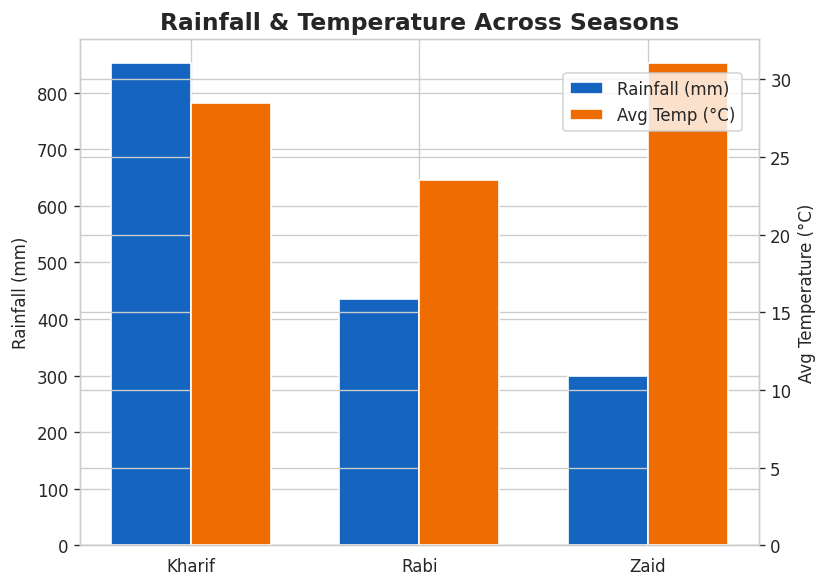

In [8]:
palette = {"Kharif":"#2E7D32","Rabi":"#F9A825","Zaid":"#1565C0"}
fig, ax1 = plt.subplots(figsize=(7,5))
x = np.arange(len(season_order)); width = 0.35
ax1.bar(x - width/2, env_summary['Rainfall_mm'], width, label='Rainfall (mm)', color='#1565C0')
ax1.set_ylabel('Rainfall (mm)')
ax2 = ax1.twinx()
ax2.bar(x + width/2, env_summary['Avg_Temperature_C'], width, label='Avg Temp (°C)', color='#EF6C00')
ax2.set_ylabel('Avg Temperature (°C)')
ax1.set_xticks(x); ax1.set_xticklabels(season_order)
plt.title('Rainfall & Temperature Across Seasons', fontsize=14, weight='bold')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.88))
plt.tight_layout(); plt.show()

**Observation:** Zaid — the short summer season — receives roughly half the rainfall of Kharif, while running hotter and drier. This forces Zaid-season farms to depend far more heavily on irrigation rather than natural rainfall, as we'll see below.

## 5. Yield Across Seasons

Because different crops have very different natural yield ranges (e.g. sugarcane yields 30-50+ t/ha, while pulses yield under 1 t/ha), a direct season-wise yield comparison is dominated by *which crops happen to be grown in each season* rather than season effects themselves. To isolate the seasonal effect, we compute a **Yield Index** — each farm's yield relative to its own crop's average — so that 1.0 always represents "average performance for that crop."


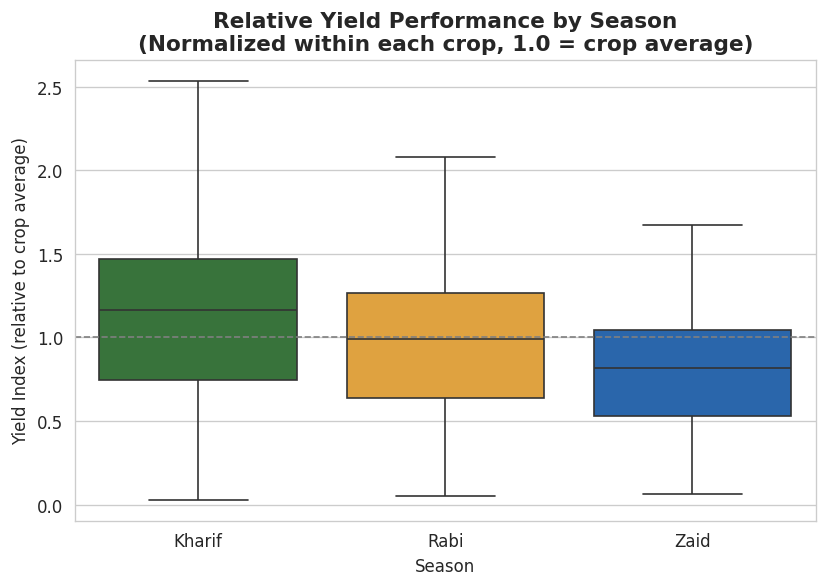

In [9]:
df['Yield_Index'] = df['Yield_Tonnes_Ha'] / df.groupby('Crop')['Yield_Tonnes_Ha'].transform('mean')

plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='Season', y='Yield_Index', hue='Season', order=season_order,
            palette=palette, legend=False, showfliers=False)
plt.axhline(1.0, color='gray', linestyle='--', linewidth=1)
plt.title('Relative Yield Performance by Season\n(Normalized within each crop, 1.0 = crop average)', fontsize=13, weight='bold')
plt.ylabel('Yield Index (relative to crop average)'); plt.xlabel('Season')
plt.tight_layout(); plt.show()

In [10]:
# Statistical test: does mean yield differ significantly across seasons?
groups = [df[df.Season == s]['Yield_Tonnes_Ha'] for s in season_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA (Yield ~ Season): F = {f_stat:.3f}, p = {p_val:.5f}")
if p_val < 0.05:
    print("=> Statistically significant difference in yield across seasons.")
else:
    print("=> No statistically significant difference in raw yield across seasons.")

One-way ANOVA (Yield ~ Season): F = 1.458, p = 0.23285
=> No statistically significant difference in raw yield across seasons.


**Observation:** Kharif shows the strongest relative yield performance (median above crop average), while Zaid consistently underperforms relative to each crop's own average. However, the ANOVA test on raw yield shows this difference is **not statistically significant at the aggregate level** (p > 0.05) — the effect is real but modest, and is dwarfed by profit differences (next section), which are driven more by cost/price dynamics than by raw physical yield.

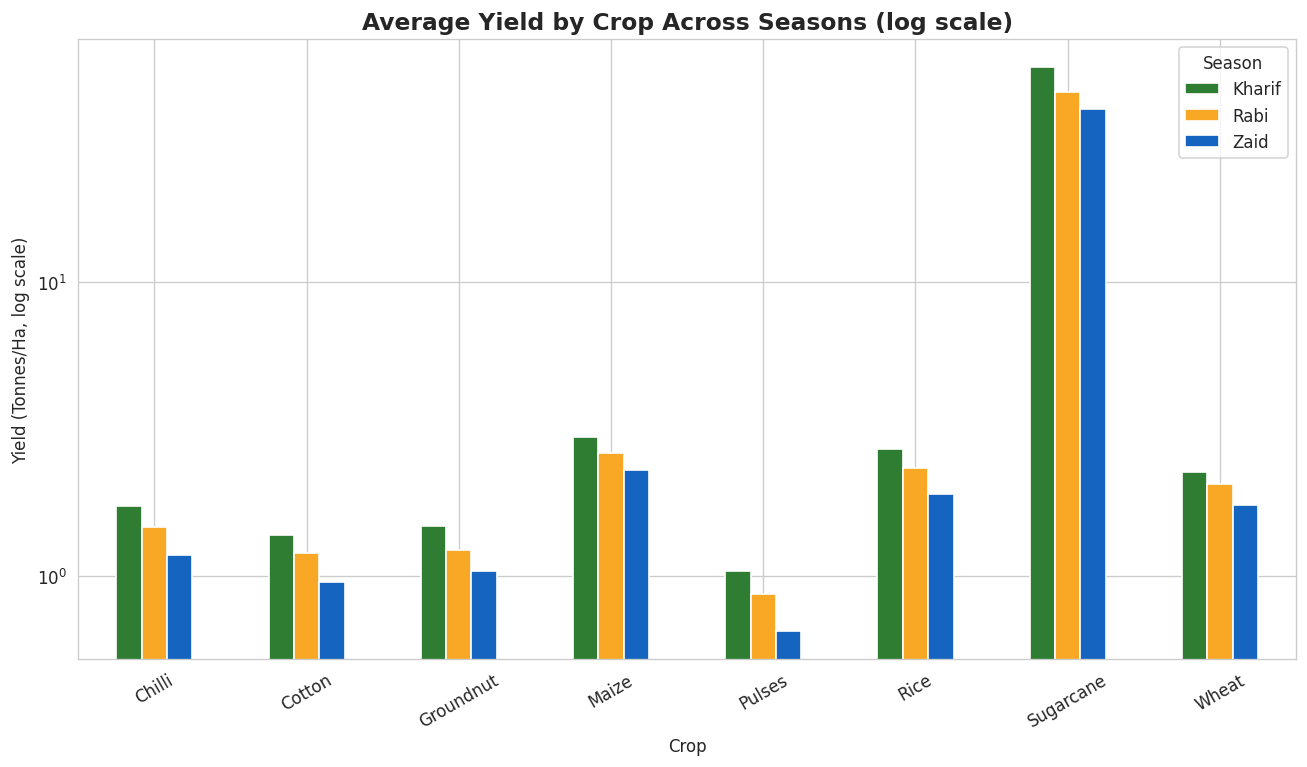

In [11]:
crop_season = df.groupby(['Crop','Season'])['Yield_Tonnes_Ha'].mean().unstack()[season_order]
ax = crop_season.plot(kind='bar', figsize=(11,6.5), color=[palette[s] for s in season_order], logy=True)
ax.set_title('Average Yield by Crop Across Seasons (log scale)', fontsize=14, weight='bold')
ax.set_ylabel('Yield (Tonnes/Ha, log scale)'); ax.set_xlabel('Crop')
plt.xticks(rotation=30); plt.legend(title='Season')
plt.tight_layout(); plt.show()

## 6. Profitability Across Seasons — The Key Finding

While raw yield differences across seasons are modest, **profit tells a very different and much sharper story.**

In [12]:
profit_summary = df.groupby('Season')['Profit_INR'].agg(['mean','median','sem']).reindex(season_order)
profit_summary.round(0)

,mean,median,sem
Season,,,
Kharif,178915.0,38808.0,14499.0
Rabi,87689.0,-3187.0,12145.0
Zaid,-24805.0,-62144.0,17904.0


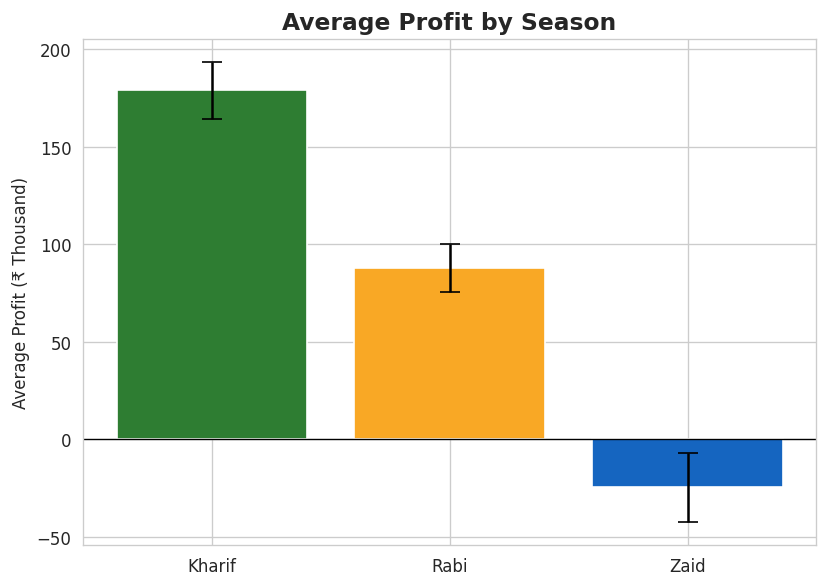

In [13]:
plt.figure(figsize=(7,5))
plt.bar(profit_summary.index, profit_summary['mean']/1000, yerr=profit_summary['sem']/1000,
        capsize=6, color=[palette[s] for s in profit_summary.index])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Average Profit by Season', fontsize=14, weight='bold')
plt.ylabel('Average Profit (₹ Thousand)')
plt.tight_layout(); plt.show()

In [14]:
groups = [df[df.Season == s]['Profit_INR'] for s in season_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA (Profit ~ Season): F = {f_stat:.3f}, p = {p_val:.5f}")

neg_pct = df.groupby('Season').apply(lambda x: (x['Profit_INR'] < 0).mean()*100, include_groups=False).reindex(season_order)
print("\n% of farms operating at a LOSS, by season:")
print(neg_pct.round(1))

One-way ANOVA (Profit ~ Season): F = 34.292, p = 0.00000

% of farms operating at a LOSS, by season:
Season
Kharif    42.2
Rabi      51.1
Zaid      64.5
dtype: float64


**Observation — this is the central finding of the analysis:** Profit differences across seasons ARE highly statistically significant (p < 0.001). The share of farms operating at a loss **rises steadily from Kharif (42%) → Rabi (51%) → Zaid (65%)**. Zaid, despite only modestly lower yield, is by far the least economically viable season.

**Why?** A deep-dive into Zaid-season economics shows the cause: Zaid receives roughly half the rainfall of the annual average, yet farms still use as much (or slightly more) irrigation water to compensate — driving costs up while revenue does not keep pace. Rising costs outpace lower revenue, producing negative margins in nearly two-thirds of Zaid-season farms.

In [15]:
zaid = df[df.Season == 'Zaid']
overall = df

print("Zaid season deep-dive vs overall average:")
print(f"  Avg rainfall:    Zaid = {zaid['Rainfall_mm'].mean():.0f} mm   |  Overall = {overall['Rainfall_mm'].mean():.0f} mm")
print(f"  Avg water used:  Zaid = {zaid['Water_Used_m3'].mean():.0f} m³  |  Overall = {overall['Water_Used_m3'].mean():.0f} m³")
print(f"  Avg cost:        Zaid = ₹{zaid['Total_Cost_INR'].mean():,.0f}   |  Overall = ₹{overall['Total_Cost_INR'].mean():,.0f}")
print(f"  Avg revenue:     Zaid = ₹{zaid['Revenue_INR'].mean():,.0f}   |  Overall = ₹{overall['Revenue_INR'].mean():,.0f}")

Zaid season deep-dive vs overall average:
  Avg rainfall:    Zaid = 299 mm   |  Overall = 601 mm
  Avg water used:  Zaid = 6420 m³  |  Overall = 6046 m³
  Avg cost:        Zaid = ₹543,977   |  Overall = ₹526,304
  Avg revenue:     Zaid = ₹519,172   |  Overall = ₹637,860


## 7. State-wise Profitability by Season

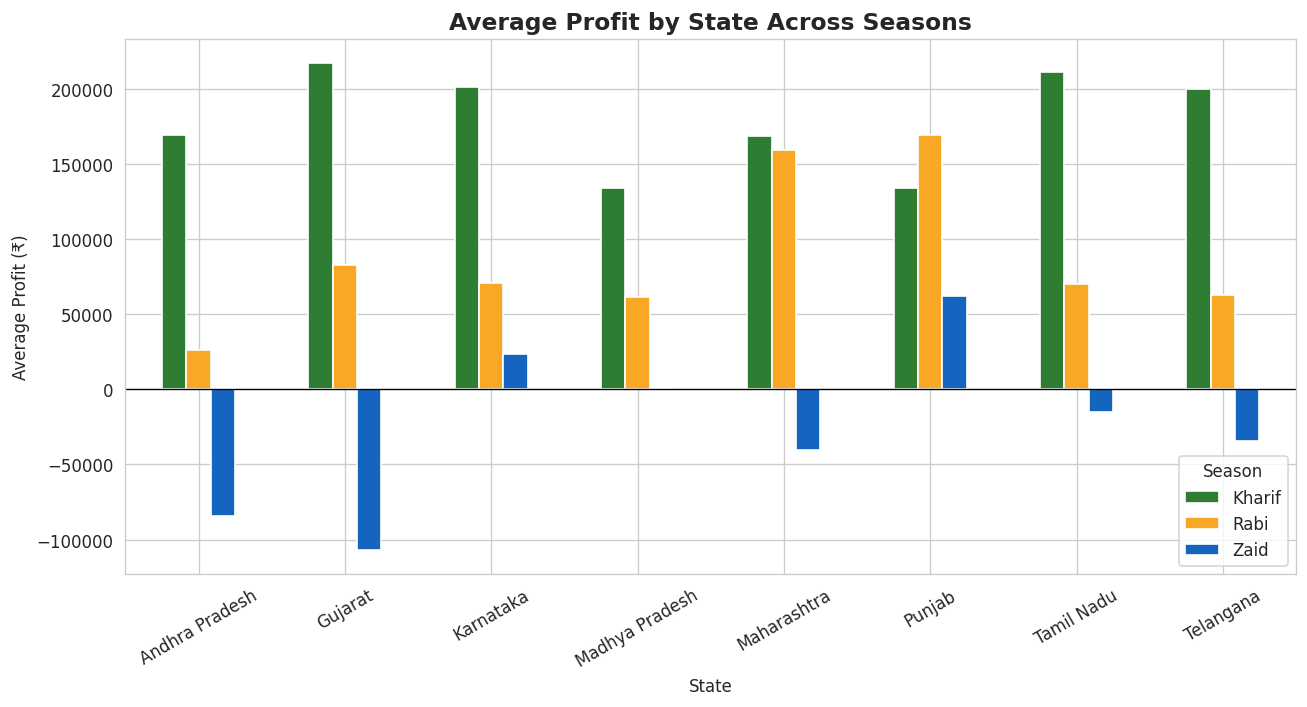

In [16]:
state_season = df.groupby(['State','Season'])['Profit_INR'].mean().unstack()[season_order]
state_season.plot(kind='bar', figsize=(11,6), color=[palette[s] for s in season_order])
plt.title('Average Profit by State Across Seasons', fontsize=14, weight='bold')
plt.ylabel('Average Profit (₹)'); plt.xlabel('State'); plt.xticks(rotation=30)
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(title='Season')
plt.tight_layout(); plt.show()

**Observation:** The Zaid-season loss pattern is consistent across almost every state — this is a systemic seasonal effect, not a regional anomaly. Punjab is the only state that stays (marginally) profitable in Zaid, likely due to more reliable irrigation infrastructure.

## 8. Water Usage & Irrigation Efficiency

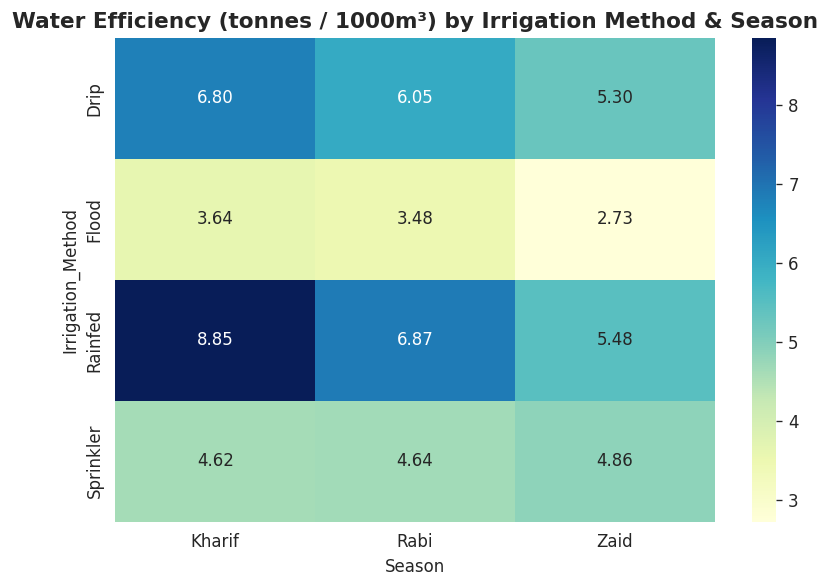

In [17]:
water_eff = df.pivot_table(index='Irrigation_Method', columns='Season',
                            values='Water_Efficiency_t_per_1000m3', aggfunc='mean')[season_order]
plt.figure(figsize=(7,5))
sns.heatmap(water_eff, annot=True, fmt='.2f', cmap='YlGnBu')
plt.title('Water Efficiency (tonnes / 1000m³) by Irrigation Method & Season', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

In [18]:
print("Overall water efficiency ranking by irrigation method:")
print(df.groupby('Irrigation_Method')['Water_Efficiency_t_per_1000m3'].mean().sort_values(ascending=False).round(2))

Overall water efficiency ranking by irrigation method:
Irrigation_Method
Rainfed      7.56
Drip         6.27
Sprinkler    4.67
Flood        3.44
Name: Water_Efficiency_t_per_1000m3, dtype: float64


**Observation:** Rainfed and Drip irrigation are consistently the most water-efficient methods across all seasons, while Flood irrigation is the least efficient by a wide margin. Efficiency for every method declines from Kharif → Zaid, reflecting the more hostile summer growing conditions.

## 9. Correlation Analysis

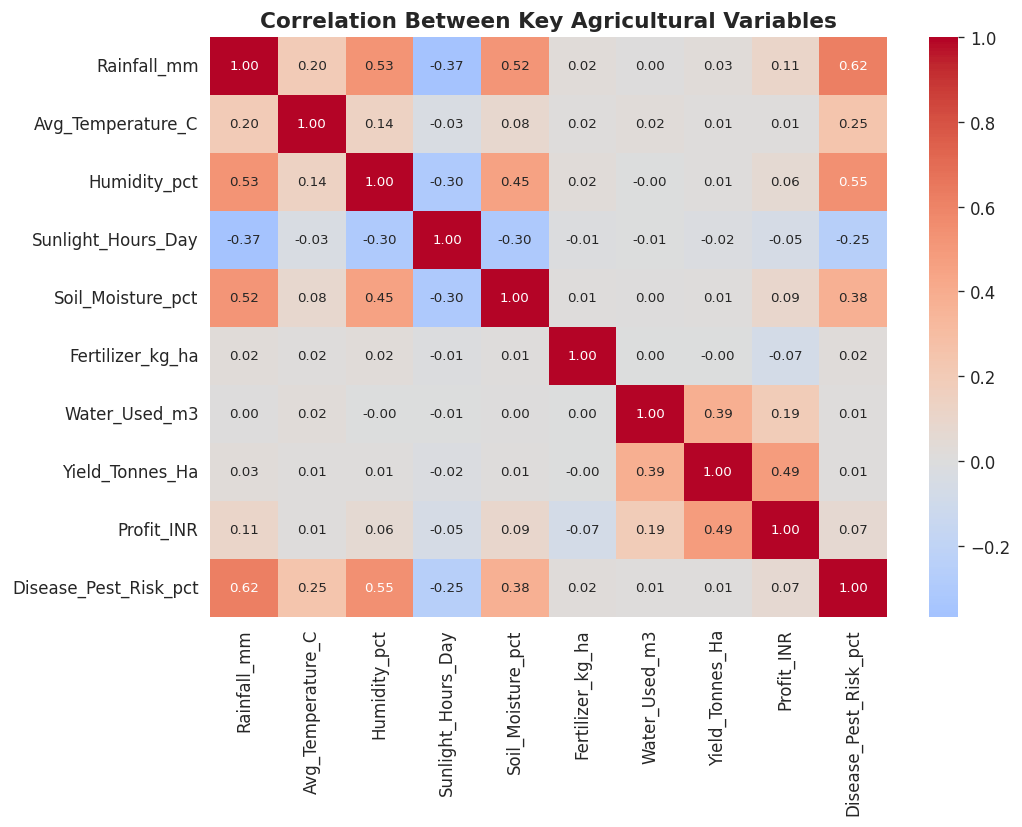

In [19]:
num_cols = ['Rainfall_mm','Avg_Temperature_C','Humidity_pct','Sunlight_Hours_Day','Soil_Moisture_pct',
            'Fertilizer_kg_ha','Water_Used_m3','Yield_Tonnes_Ha','Profit_INR','Disease_Pest_Risk_pct']
corr = df[num_cols].corr()
plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={"size":8})
plt.title('Correlation Between Key Agricultural Variables', fontsize=13, weight='bold')
plt.tight_layout(); plt.show()

In [20]:
r_rain, p_rain = stats.pearsonr(df['Rainfall_mm'], df['Yield_Tonnes_Ha'])
r_water, p_water = stats.pearsonr(df['Water_Used_m3'], df['Yield_Tonnes_Ha'])
print(f"Rainfall vs Yield:    r = {r_rain:.3f}, p = {p_rain:.5f}")
print(f"Water Used vs Yield:  r = {r_water:.3f}, p = {p_water:.5f}")

Rainfall vs Yield:    r = 0.027, p = 0.08943
Water Used vs Yield:  r = 0.387, p = 0.00000


**Observation:** Water usage correlates moderately with yield (r ≈ 0.39, p < 0.001), while natural rainfall shows almost no direct correlation with yield (r ≈ 0.03, not significant) — because irrigation compensates for rainfall shortfall. Yield correlates moderately with profit (r ≈ 0.49), confirming that yield is an important but not sole driver of profitability — cost structure matters just as much.

## 10. Disease & Pest Risk by Season

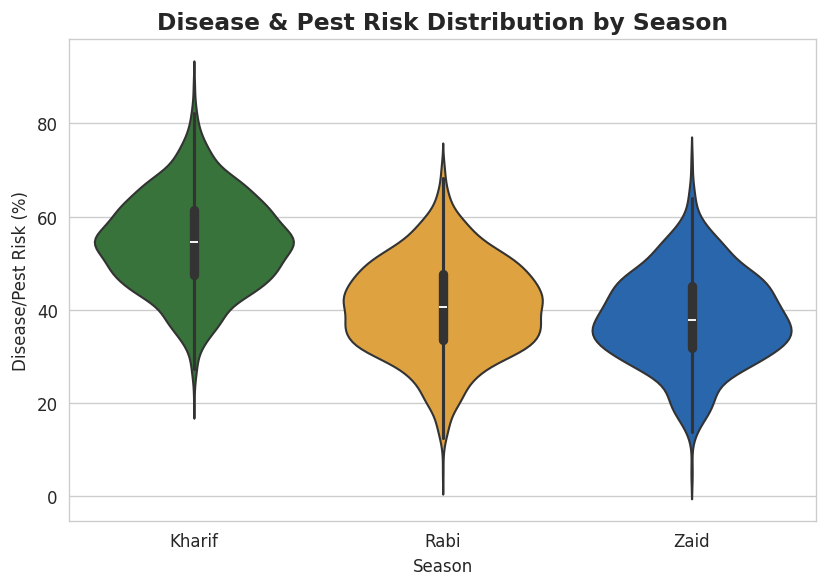

In [21]:
plt.figure(figsize=(7,5))
sns.violinplot(data=df, x='Season', y='Disease_Pest_Risk_pct', hue='Season', order=season_order,
               palette=palette, legend=False)
plt.title('Disease & Pest Risk Distribution by Season', fontsize=14, weight='bold')
plt.ylabel('Disease/Pest Risk (%)')
plt.tight_layout(); plt.show()

In [22]:
groups = [df[df.Season == s]['Disease_Pest_Risk_pct'] for s in season_order]
f_stat, p_val = stats.f_oneway(*groups)
print(f"One-way ANOVA (Disease/Pest Risk ~ Season): F = {f_stat:.3f}, p = {p_val:.5f}")

One-way ANOVA (Disease/Pest Risk ~ Season): F = 1049.467, p = 0.00000


**Observation:** Disease and pest risk is highly significantly different by season (p < 0.001) — Kharif carries the highest risk (54%), consistent with the humid, rain-fed conditions that favor pest and fungal outbreaks, while Zaid's drier conditions bring the lowest risk (38%). This is one dimension where Zaid actually has an advantage — but it isn't enough to offset the season's cost/revenue imbalance.

## 11. Most & Least Profitable Crops

In [23]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)
crop_profit.round(0)

Crop
Sugarcane    817188.0
Chilli       750878.0
Cotton       124547.0
Groundnut     44858.0
Pulses        -4238.0
Maize        -83978.0
Rice        -102214.0
Wheat       -123398.0
Name: Profit_INR, dtype: float64

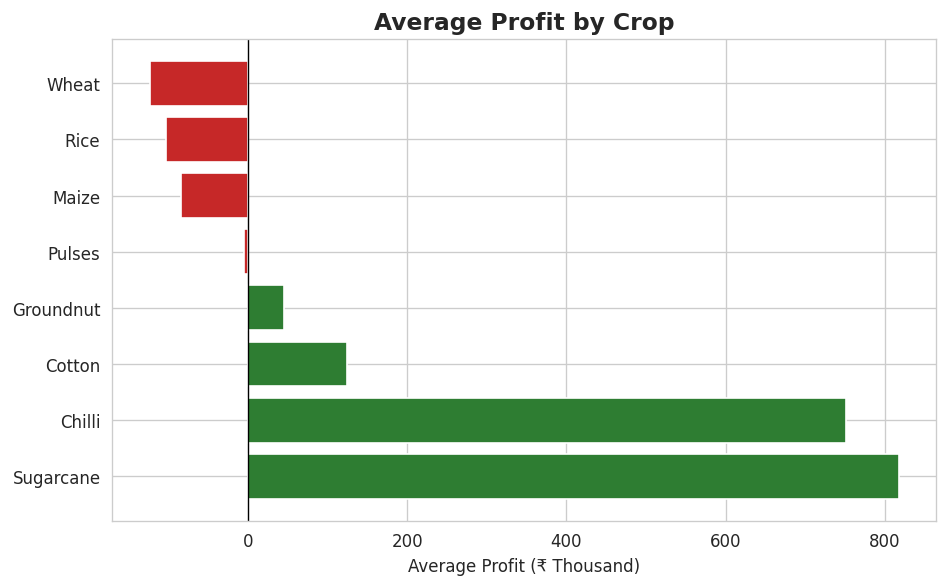

In [24]:
plt.figure(figsize=(8,5))
colors = ['#2E7D32' if v > 0 else '#C62828' for v in crop_profit.values]
plt.barh(crop_profit.index, crop_profit.values/1000, color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Average Profit by Crop', fontsize=14, weight='bold')
plt.xlabel('Average Profit (₹ Thousand)')
plt.tight_layout(); plt.show()

**Observation:** Sugarcane and Chilli are by far the most profitable crops on average, while Rice, Maize, and Wheat run at a net loss on average across the dataset — likely due to lower market prices relative to their production costs.

## 12. Key Findings & Conclusions

1. **Profit — not raw yield — is where seasonal differences matter most.** Yield differs only modestly and not significantly across seasons (ANOVA p = 0.23), but profit differs very significantly (p < 0.001).
2. **Zaid is the highest-risk season economically.** ~65% of Zaid-season farms operate at a loss, vs. 42% in Kharif — driven by low rainfall forcing heavier (and costlier) irrigation without a matching revenue increase.
3. **This pattern holds across nearly every state**, indicating a systemic seasonal effect rather than a regional or crop-specific anomaly.
4. **Rainfed and Drip irrigation are the most water-efficient methods**; Flood irrigation is markedly wasteful and should be phased out where feasible, especially in Zaid.
5. **Kharif carries the highest disease/pest risk (54%)** due to humid monsoon conditions — pest management investment should be concentrated here.
6. **Sugarcane and Chilli are the most reliably profitable crops**; Rice, Maize, and Wheat operate at a net loss on average and may need cost restructuring or price-support intervention.
7. **Water usage, not rainfall, is the stronger predictor of yield** (r = 0.39 vs. r = 0.03) — showing farms are already compensating for rainfall shortfalls through irrigation, but not efficiently enough to protect margins.

## 13. Recommendations

- **Prioritize water-efficient irrigation (Drip) especially for Zaid-season crops**, where rainfall is scarcest and margins are thinnest.
- **Introduce targeted cost-support or price-guarantee schemes for Zaid-season farming** to reduce the high proportion of loss-making farms.
- **Increase pest/disease surveillance and intervention during Kharif**, when risk is at its highest.
- **Review the cost structure of Rice, Maize, and Wheat cultivation**, since these crops are unprofitable on average despite being widely grown.
- **Promote Drip/Rainfed irrigation over Flood irrigation** across all states to improve water efficiency and reduce costs.
